# Logistic Regression — Classification (Google Colab)

**Goal:** Predict a **binary class** (0/1) using **Logistic Regression** — outputs **probabilities** via the **sigmoid** function.

| Example | Feature(s) (X) | Target (y) | Dataset |
|---------|----------------|------------|---------|
| **Example 1** | Age, EstimatedSalary | Purchased (0/1) | `../Datasets/social_network_ads.csv` |
| **Example 2** | CreditScore, Income, LoanAmount, YearsEmployed | Approved (0/1) | `../Datasets/loan_approval.csv` |

| Phase | Topic | Cells |
|-------|-------|-------|
| Phase 0 | Setup | Install & Imports |
| — | Algorithm Guide | Sigmoid, log-odds, threshold |
| Phase 1 | Data Pre-processing | Load → Cleaning → Encoding → Split |
| Phase 2 | Algorithm | Train → Predict → Visualize → Evaluate |

> **Run:** Runtime → Run all (or Ctrl+F9)

---
# Algorithm Guide — Logistic Regression (Classification)

## What is Classification?

**Classification** predicts a **discrete class label** (e.g. Purchased = 0 or 1), not a continuous number.

| Task | Output | Example Algorithm |
|------|--------|-------------------|
| **Regression** | Continuous number | Linear Regression |
| **Classification** | Class label (0/1) | **Logistic Regression** |

## Why Not Linear Regression for Classification?

| Problem | Explanation |
|---------|-------------|
| Invalid outputs | Linear regression can predict values **< 0** or **> 1** |
| Wrong objective | Minimizes squared error — not suited for class labels |
| No probability | Does not naturally output valid probabilities |

## Logistic Regression Idea

1. Compute a **linear score**: `z = β₀ + β₁x₁ + β₂x₂ + ...`
2. Pass through **sigmoid** to get probability: `P(y=1|x) = σ(z) = 1 / (1 + e⁻ᶻ)`
3. Apply **threshold** (default **0.5**): if P ≥ 0.5 → class **1**, else class **0**

## Sigmoid Function

| z | σ(z) |
|---|------|
| Large positive | → 1 |
| 0 | → 0.5 |
| Large negative | → 0 |

**Key property:** Output is always between **0 and 1** — a valid probability.

## Log-Odds (Logit)

`log(P / (1−P)) = β₀ + β₁x₁ + β₂x₂ + ...`

Logistic Regression models the **log-odds** as a linear function of features.

## Key Hyperparameters (sklearn)

| Parameter | Role |
|-----------|------|
| `C` | Inverse of regularization strength (smaller C = stronger penalty) |
| `max_iter` | Maximum iterations for solver convergence |
| `random_state` | Reproducible results |
| `class_weight` | Handle imbalanced classes (`'balanced'` if needed) |

## Feature Scaling

Use **`StandardScaler`** when features have different scales (Age vs Salary, Credit vs Income). Scaling helps the optimizer and makes coefficients comparable.

## Classification Metrics

| Metric | Formula / Meaning |
|--------|-------------------|
| **Accuracy** | (TP + TN) / Total |
| **Precision** | TP / (TP + FP) — of predicted Yes, how many are correct |
| **Recall** | TP / (TP + FN) — of actual Yes, how many we caught |
| **F1 Score** | Harmonic mean of Precision and Recall |

## Confusion Matrix

|  | Pred 0 | Pred 1 |
|--|--------|--------|
| **Actual 0** | TN | FP |
| **Actual 1** | FN | TP |

## What the Student Must Remember

1. Logistic Regression outputs **probabilities** in [0, 1].
2. Final class uses a **threshold** (usually 0.5).
3. Use **classification metrics** — not R² or RMSE.
4. **Scale features** when units differ widely.
5. Use **`stratify=y`** in train_test_split to keep class balance.

## Phase 0 — Cell 0: Install Libraries

Google Colab usually includes most libraries. This cell ensures required packages are available.

**What this cell does:** Installs scikit-learn, pandas, matplotlib, numpy, and seaborn quietly.

In [23]:
# Install into the same Python as this notebook kernel (avoids pip/kernel mismatch)
import sys
!{sys.executable} -m pip install -q scikit-learn pandas matplotlib numpy


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


## Phase 0 — Cell 1: Import Libraries

Import libraries for preprocessing, Logistic Regression, and classification evaluation.

**What this cell does:** Loads numpy, pandas, matplotlib, sklearn classifiers and metrics.

In [24]:
# --- Import libraries ---
import numpy as np              # Numerical operations and arrays
import pandas as pd             # Load and manipulate tabular data
import matplotlib.pyplot as plt # Create charts and plots
from matplotlib.colors import ListedColormap  # Colors for decision regions

from sklearn.model_selection import train_test_split       # Split data into train/test
from sklearn.impute import SimpleImputer                   # Fill missing values
from sklearn.preprocessing import StandardScaler           # Feature scaling
from sklearn.pipeline import Pipeline                      # Chain scaler + classifier
from sklearn.linear_model import LogisticRegression        # Logistic Regression classifier
from sklearn.metrics import (                              # Classification metrics
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

plt.rcParams['figure.figsize'] = (10, 6)  # Default plot size: width=10, height=6 inches
plt.style.use('seaborn-v0_8-whitegrid')   # Clean white background with grid lines
np.random.seed(42)                          # Fix random seed for reproducible splits

print('Libraries ready')                      # Confirm all imports loaded successfully

Libraries ready


---
# Example 1: Social Network Ads — Logistic Regression

Predict whether a user **Purchased** a product from **Age** and **EstimatedSalary**.

| Column | Role | Description |
|--------|------|-------------|
| `Age` | Feature (X₁) | User age in years |
| `EstimatedSalary` | Feature (X₂) | Estimated annual salary in USD |
| `Purchased` | Target (y) | 0 = No, 1 = Yes |

**File:** `../Datasets/social_network_ads.csv`

---
# Phase 1: Data Pre-processing

Prepare the data before training — same template is reused for other algorithms.

## Example 1 — Cell 1: Load and Explore Data

Load the CSV file and perform initial exploration (head, info, describe, shape).

**What this cell does:** Reads `../Datasets/social_network_ads.csv` and displays basic statistics.

In [25]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/social_network_ads.csv')  # Read CSV into a DataFrame

FEATURE_COLS = ['Age', 'EstimatedSalary']  # Two numeric input features
TARGET_COL = 'Purchased'                    # Binary target: 0 = No, 1 = Yes

print('First 5 rows:')          # Print a label for the table below
display(dataset.head())         # Show the first 5 rows to inspect the data

print('\nDataset info:')       # Print a label for column types and null counts
dataset.info()                  # Show column names, data types, and non-null counts

print('\nStatistical summary:')  # Print a label for numeric statistics
display(dataset.describe())       # Show count, mean, std, min, max, quartiles

print(f'\nClass balance ({TARGET_COL}):')  # Show how many 0 vs 1
print(dataset[TARGET_COL].value_counts())   # Count per class

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')  # Total rows and columns

First 5 rows:


,Age,EstimatedSalary,Purchased
0,56,115235,1
1,46,89740,1
2,32,131352,1
3,60,81617,0
4,25,31896,0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB

Statistical summary:


,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,39.605000,80844.840000,0.420000
std,12.374846,39484.169884,0.494177
min,18.000000,15404.000000,0.000000
25%,29.000000,42699.750000,0.000000
50%,41.000000,81218.500000,0.000000
75%,50.000000,117134.250000,1.000000
max,60.000000,149668.000000,1.000000



Class balance (Purchased):
Purchased
0    232
1    168
Name: count, dtype: int64

Shape: 400 rows x 3 columns


## Example 1 — Cell 2: Data Cleaning (Handling Missing Values)

Check missing values, remove duplicates, and apply imputation if needed.

**What this cell does:** Cleans the dataset before modeling.

In [26]:
# Step 2) Data cleaning

print('Missing values per column:')  # Print a label
print(dataset.isnull().sum())        # Count NaN values in each column

rows_before = len(dataset)                              # Store row count before cleaning
dataset = dataset.drop_duplicates().reset_index(drop=True)  # Remove duplicate rows
rows_after = len(dataset)                               # Store row count after deduplication
print(f'\nDuplicates removed: {rows_before - rows_after}')  # Show duplicate count

num_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()  # Numeric columns only
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')  # Fill NaN with column mean
if dataset.isnull().sum().sum() > 0:               # If missing values exist
    dataset[num_cols] = imputer.fit_transform(dataset[num_cols])  # Impute numeric columns
    print('Missing values imputed with mean')      # Confirm imputation
else:
    print('No missing values — imputer not applied')  # Skip when complete

print(f'\nRows after cleaning: {rows_after}')    # Final row count

Missing values per column:
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Duplicates removed: 0
No missing values — imputer not applied

Rows after cleaning: 400


## Example 1 — Cell 3: Categorical Data Encoding

All columns are numeric — encoding is skipped.

**What this cell does:** Confirms no categorical encoding is needed.

In [27]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()  # Find text columns
if cat_cols:
    print(f'Categorical columns found: {cat_cols}')
else:
    print('No categorical columns — encoding skipped.')
    print(f'Feature columns: {FEATURE_COLS}')
    print(f'Target column: {TARGET_COL} (already 0/1)')

No categorical columns — encoding skipped.
Feature columns: ['Age', 'EstimatedSalary']
Target column: Purchased (already 0/1)


## Example 1 — Cell 4: Splitting the Data

Define X (features) and y (Purchased), then split 80/20 with **stratify** to preserve class ratio.

**What this cell does:** Creates feature/target arrays and applies stratified train_test_split.

In [28]:
# Step 4) Train-Test split (stratified for classification)

X = dataset[FEATURE_COLS].values  # Feature matrix: Age and EstimatedSalary
y = dataset[TARGET_COL].values    # Target vector: Purchased (0 or 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                  # Data to split
    test_size=0.2,         # 20% test, 80% train
    random_state=42,       # Reproducible split
    stratify=y             # Keep same class ratio in train and test
)

print(f'X_train shape: {X_train.shape}')  # Training features shape
print(f'X_test shape:  {X_test.shape}')   # Test features shape
print(f'y_train class counts: {np.bincount(y_train)}')  # [count_0, count_1] in train
print(f'y_test class counts:  {np.bincount(y_test)}')   # [count_0, count_1] in test

X_train shape: (320, 2)
X_test shape:  (80, 2)
y_train class counts: [186 134]
y_test class counts:  [46 34]


> **Note:** Logistic Regression works best with **scaled features** when Age and Salary have different units — we use `StandardScaler` in the pipeline.

---
# Phase 2: Logistic Regression — Social Network Ads

Train a classifier to predict Purchased from Age and EstimatedSalary.

## Example 1 — Cell 5: Train the Model

Build a **Pipeline**: StandardScaler → LogisticRegression.

**What this cell does:** Fits the classifier and prints learned coefficients.

In [29]:
# Step 5) Train Logistic Regression

classifier = Pipeline([
    ('scaler', StandardScaler()),  # Scale Age and Salary to mean=0, std=1
    ('model', LogisticRegression(random_state=42))  # Binary logistic classifier
])

classifier.fit(X_train, y_train)  # Learn coefficients on training data

model = classifier.named_steps['model']  # Extract fitted LogisticRegression
print('Logistic Regression trained successfully.')
print(f'Intercept (β₀): {model.intercept_[0]:.4f}')  # Bias term
for name, coef in zip(FEATURE_COLS, model.coef_[0]):
    print(f'  {name:18s} -> β = {coef:.4f}')  # One coefficient per feature

Logistic Regression trained successfully.
Intercept (β₀): -0.5169
  Age                -> β = 1.2666
  EstimatedSalary    -> β = 1.4346


## Example 1 — Cell 6: Predict

Predict class labels and **probabilities** on the test set.

**What this cell does:** Uses `predict()` for classes and `predict_proba()` for P(Purchased=1).

In [30]:
# Step 6) Predict classes and probabilities

y_pred_train = classifier.predict(X_train)            # Class labels (0 or 1) for training set
y_pred_test = classifier.predict(X_test)              # Class labels for test set
y_proba_test = classifier.predict_proba(X_test)[:, 1]  # P(Purchased=1) for each test sample

print('Sample predictions (Test set):')
for i in range(min(5, len(y_test))):
    label = 'Yes' if y_pred_test[i] == 1 else 'No'
    actual = 'Yes' if y_test[i] == 1 else 'No'
    print(f'  Actual={actual}, Predicted={label}, P(Purchase)={y_proba_test[i]:.2%}')

Sample predictions (Test set):
  Actual=No, Predicted=No, P(Purchase)=10.75%
  Actual=Yes, Predicted=Yes, P(Purchase)=80.22%
  Actual=Yes, Predicted=No, P(Purchase)=20.34%
  Actual=No, Predicted=No, P(Purchase)=22.87%
  Actual=No, Predicted=No, P(Purchase)=28.59%


## Example 1 — Cell 7: Visualization

Plot data points colored by class and the **decision boundary** (where P = 0.5).

**What this cell does:** Shows how Logistic Regression separates Purchased vs Not Purchased.

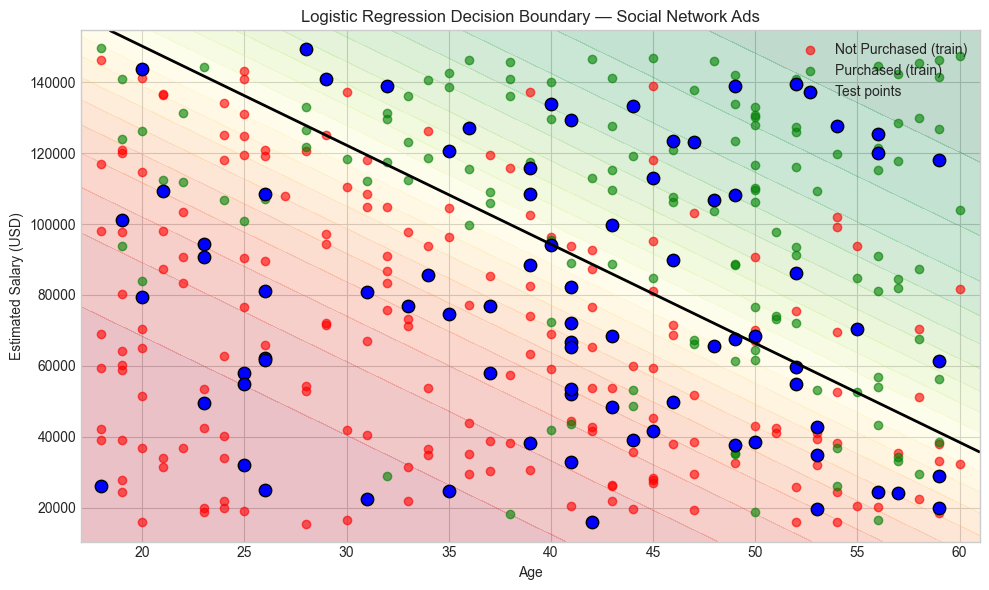

In [31]:
# Step 7) Visualization — scatter + decision boundary

# --- Build mesh grid for decision regions ---
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1          # Age range with padding
y_min, y_max = X[:, 1].min() - 5000, X[:, 1].max() + 5000   # Salary range with padding
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),      # 300 Age grid points
    np.linspace(y_min, y_max, 300)       # 300 Salary grid points
)
grid = np.c_[xx.ravel(), yy.ravel()]     # Flatten grid to (n_points, 2)
Z = classifier.predict_proba(grid)[:, 1]  # P(Purchased=1) at each grid point
Z = Z.reshape(xx.shape)                   # Reshape back to 2D for contour plot

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn', levels=20)  # Probability heatmap
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)  # Decision boundary at 0.5
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='red', label='Not Purchased (train)', alpha=0.6)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='green', label='Purchased (train)', alpha=0.6)
plt.scatter(X_test[:, 0], X_test[:, 1], c='blue', edgecolors='k', s=80, label='Test points')
plt.xlabel('Age')
plt.ylabel('Estimated Salary (USD)')
plt.title('Logistic Regression Decision Boundary — Social Network Ads')
plt.legend()
plt.tight_layout()
plt.show()

## Example 1 — Cell 8: Evaluation

Evaluate with **Accuracy**, **Precision**, **Recall**, **F1**, and **Confusion Matrix**.

**What this cell does:** Computes classification metrics on the test set.

,Metric,Value,Description
0,Accuracy,0.8375,Fraction of correct predictions
1,Precision,0.8889,"Of predicted Yes, fraction actually Yes"
2,Recall,0.7059,"Of actual Yes, fraction correctly predicted"
3,F1 Score,0.7869,Balance between Precision and Recall



Confusion Matrix (rows=Actual, cols=Predicted):
[[43  3]
 [10 24]]


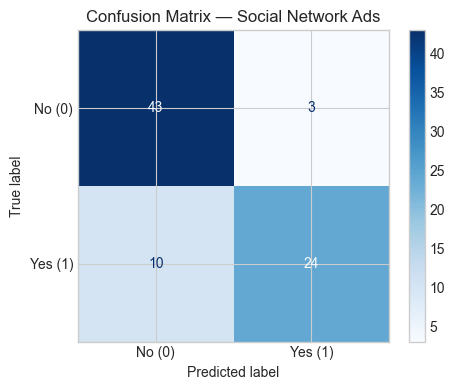


Example 1 Test Accuracy = 0.8375


In [32]:
# Step 8) Evaluation — classification metrics

acc = accuracy_score(y_test, y_pred_test)                    # Overall correct predictions
prec = precision_score(y_test, y_pred_test, zero_division=0) # TP / (TP + FP)
rec = recall_score(y_test, y_pred_test, zero_division=0)   # TP / (TP + FN)
f1 = f1_score(y_test, y_pred_test, zero_division=0)        # Harmonic mean of precision & recall

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [acc, prec, rec, f1],
    'Description': [
        'Fraction of correct predictions',
        'Of predicted Yes, fraction actually Yes',
        'Of actual Yes, fraction correctly predicted',
        'Balance between Precision and Recall'
    ]
})

display(results.round(4))  # Show metrics table

cm = confusion_matrix(y_test, y_pred_test)  # 2×2 matrix: TN, FP, FN, TP
print('\nConfusion Matrix (rows=Actual, cols=Predicted):')
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Yes (1)']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix — Social Network Ads')
plt.tight_layout()
plt.show()

print(f'\nExample 1 Test Accuracy = {acc:.4f}')

## Why does Logistic Regression work for Social Network Ads?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Binary target** | Purchased is 0/1 — perfect for logistic regression |
| 2 | **Two features** | Age and Salary combine into a linear log-odds score |
| 3 | **Decision boundary** | Sigmoid creates a smooth boundary in the Age–Salary plane |
| 4 | **Probabilities** | Marketing teams need P(Purchase), not just Yes/No |
| 5 | **Feature scaling** | Salary (~50k) and Age (~35) differ in scale — StandardScaler helps |

> **Summary:** Older users with higher salaries tend to purchase — logistic regression learns this boundary.

## Understanding Classification Metrics — Example 1

| Metric | When It Matters |
|--------|-----------------|
| **Accuracy** | Balanced classes — overall performance |
| **Precision** | Cost of false alarms (predicting Yes when No) |
| **Recall** | Cost of missing buyers (predicting No when Yes) |
| **F1** | Balance when classes are slightly imbalanced |

> **Not R²:** Classification uses **Accuracy / Precision / Recall / F1** — not regression metrics.

---
# Example 2: Loan Approval — Logistic Regression

Predict whether a loan is **Approved** (1) or **Rejected** (0) from applicant financial features.

| Column | Role | Description |
|--------|------|-------------|
| `CreditScore` | Feature (X₁) | Credit score (300–850) |
| `Income` | Feature (X₂) | Annual income in USD |
| `LoanAmount` | Feature (X₃) | Requested loan amount in USD |
| `YearsEmployed` | Feature (X₄) | Years at current job |
| `Approved` | Target (y) | 1 = Approved, 0 = Rejected |

**File:** `../Datasets/loan_approval.csv`

## Example 2 — Cell 1: Load and Explore Data

Load the loan approval CSV and inspect the data.

**What this cell does:** Reads `../Datasets/loan_approval.csv` and displays basic statistics.

In [33]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/loan_approval.csv')  # Read CSV into a DataFrame

FEATURE_COLS = ['CreditScore', 'Income', 'LoanAmount', 'YearsEmployed']  # Four input features
TARGET_COL = 'Approved'  # Binary target: 0 = Rejected, 1 = Approved

print('First 5 rows:')
display(dataset.head())

print('\nDataset info:')
dataset.info()

print('\nStatistical summary:')
display(dataset.describe())

print(f'\nClass balance ({TARGET_COL}):')
print(dataset[TARGET_COL].value_counts())

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')

First 5 rows:


,CreditScore,Income,LoanAmount,YearsEmployed,Approved
0,452.0,87003,152038.0,4.2,0
1,785.0,108211,134862.0,5.1,1
2,698.0,77733,128834.0,6.6,1
3,620.0,90318,103848.0,19.9,1
4,456.0,134953,62921.0,14.2,1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CreditScore    249 non-null    float64
 1   Income         250 non-null    int64  
 2   LoanAmount     249 non-null    float64
 3   YearsEmployed  250 non-null    float64
 4   Approved       250 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 9.9 KB

Statistical summary:


,CreditScore,Income,LoanAmount,YearsEmployed,Approved
count,249.000000,250.000000,249.000000,250.000000,250.000000
mean,585.995984,82134.284000,91971.630522,10.466800,0.500000
std,133.107085,34366.209563,49499.083375,5.456677,0.501003
min,351.000000,25301.000000,11062.000000,1.000000,0.000000
25%,480.000000,53138.000000,47841.000000,5.825000,0.000000
50%,583.000000,80214.000000,96900.000000,10.750000,0.500000
75%,695.000000,112522.500000,129180.000000,15.150000,1.000000
max,813.000000,137893.000000,178152.000000,19.900000,1.000000



Class balance (Approved):
Approved
0    125
1    125
Name: count, dtype: int64

Shape: 250 rows x 5 columns


## Example 2 — Cell 2: Data Cleaning (Handling Missing Values)

This dataset includes missing values in features to demonstrate `SimpleImputer`.

**What this cell does:** Checks for nulls, removes duplicates, and imputes missing values.

In [34]:
# Step 2) Data cleaning

print('Missing values per column:')
print(dataset.isnull().sum())

rows_before = len(dataset)
dataset = dataset.drop_duplicates().reset_index(drop=True)
rows_after = len(dataset)
print(f'\nDuplicates removed: {rows_before - rows_after}')

# Drop rows where target is missing (cannot train without label)
if dataset[TARGET_COL].isnull().sum() > 0:
    dataset = dataset.dropna(subset=[TARGET_COL]).reset_index(drop=True)
    print('Rows with missing target removed')

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
feature_and_target = FEATURE_COLS + [TARGET_COL]
if dataset[feature_and_target].isnull().sum().sum() > 0:
    dataset[feature_and_target] = imputer.fit_transform(dataset[feature_and_target])
    print('Missing feature values imputed with mean')
else:
    print('No missing values — imputer not applied')

print(f'\nRows after cleaning: {len(dataset)}')

Missing values per column:
CreditScore      1
Income           0
LoanAmount       1
YearsEmployed    0
Approved         0
dtype: int64

Duplicates removed: 0
Missing feature values imputed with mean

Rows after cleaning: 250


## Example 2 — Cell 3: Categorical Data Encoding

All columns are numeric — encoding is skipped.

**What this cell does:** Confirms no categorical encoding is needed.

In [35]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f'Categorical columns found: {cat_cols}')
else:
    print('No categorical columns — encoding skipped.')
    print(f'Feature columns: {FEATURE_COLS}')

No categorical columns — encoding skipped.
Feature columns: ['CreditScore', 'Income', 'LoanAmount', 'YearsEmployed']


## Example 2 — Cell 4: Splitting the Data

Define X (4 features) and y (Approved), then split 80/20 with stratify.

**What this cell does:** Creates feature/target arrays and applies stratified train_test_split.

In [36]:
# Step 4) Train-Test split

X = dataset[FEATURE_COLS].values  # Feature matrix: 4 columns
y = dataset[TARGET_COL].values.astype(int)  # Target: Approved as integer 0/1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train class counts: {np.bincount(y_train)}')
print(f'y_test class counts:  {np.bincount(y_test)}')

X_train shape: (200, 4)
X_test shape:  (50, 4)
y_train class counts: [100 100]
y_test class counts:  [25 25]


## Example 2 — Cell 5: Train the Model

Train Logistic Regression with StandardScaler on four financial features.

**What this cell does:** Fits the pipeline and prints coefficients (interpretable impact).

In [37]:
# Step 5) Train Logistic Regression

classifier = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

classifier.fit(X_train, y_train)

model = classifier.named_steps['model']
print('Logistic Regression trained successfully.')
print(f'Intercept (β₀): {model.intercept_[0]:.4f}')
print('\nCoefficients (on scaled features):')
for name, coef in zip(FEATURE_COLS, model.coef_[0]):
    print(f'  {name:15s} -> β = {coef:+.4f}')

Logistic Regression trained successfully.
Intercept (β₀): -0.0664

Coefficients (on scaled features):
  CreditScore     -> β = +1.5565
  Income          -> β = +0.4559
  LoanAmount      -> β = -0.7541
  YearsEmployed   -> β = +0.4643


## Example 2 — Cell 6: Predict

Predict loan approval on the test set with classes and probabilities.

**What this cell does:** Generates predictions and shows sample outputs.

In [38]:
# Step 6) Predict

y_pred_test = classifier.predict(X_test)
y_proba_test = classifier.predict_proba(X_test)[:, 1]

print('Sample predictions (Test set):')
for i in range(min(5, len(y_test))):
    actual = 'Approved' if y_test[i] == 1 else 'Rejected'
    pred = 'Approved' if y_pred_test[i] == 1 else 'Rejected'
    print(f'  Actual={actual}, Predicted={pred}, P(Approved)={y_proba_test[i]:.2%}')

Sample predictions (Test set):
  Actual=Approved, Predicted=Approved, P(Approved)=55.16%
  Actual=Rejected, Predicted=Rejected, P(Approved)=5.36%
  Actual=Rejected, Predicted=Rejected, P(Approved)=8.91%
  Actual=Rejected, Predicted=Rejected, P(Approved)=1.40%
  Actual=Rejected, Predicted=Approved, P(Approved)=67.82%


## Example 2 — Cell 7: Visualization

Plot **coefficient bar chart** and **confusion matrix**.

**What this cell does:** Shows which features push toward approval and overall test performance.

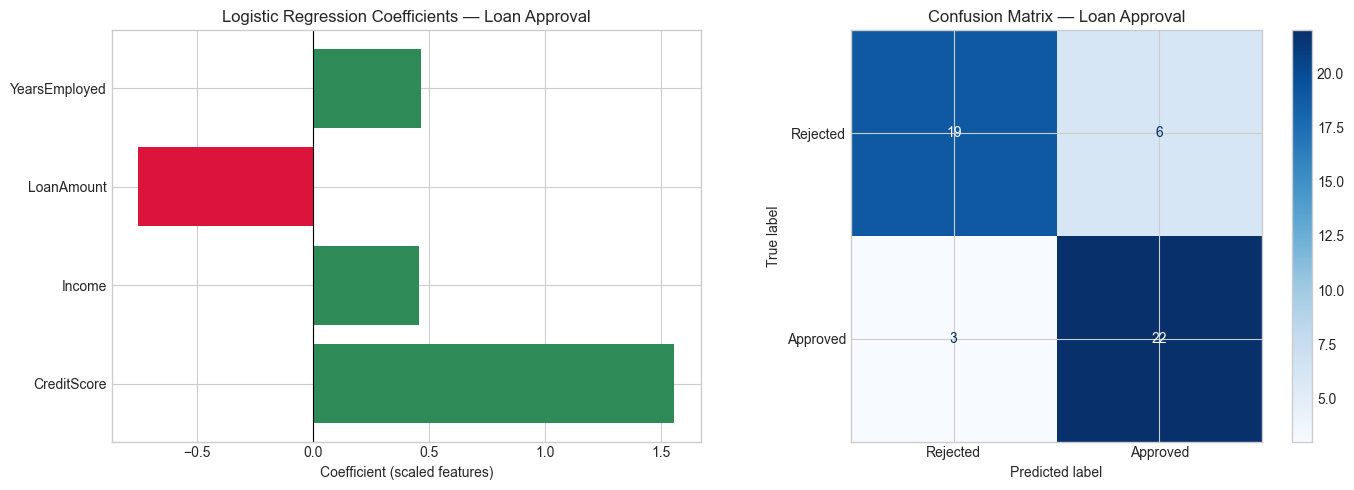

In [39]:
# Step 7) Visualization — coefficients + confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: coefficient importance ---
coefs = classifier.named_steps['model'].coef_[0]
colors = ['seagreen' if c > 0 else 'crimson' for c in coefs]
axes[0].barh(FEATURE_COLS, coefs, color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Coefficient (scaled features)')
axes[0].set_title('Logistic Regression Coefficients — Loan Approval')

# --- Right: confusion matrix ---
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix — Loan Approval')

plt.tight_layout()
plt.show()

## Example 2 — Cell 8: Evaluation

Full classification report with Accuracy, Precision, Recall, and F1.

**What this cell does:** Computes and displays evaluation metrics.

In [40]:
# Step 8) Evaluation

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [acc, prec, rec, f1],
    'Description': [
        'Fraction of correct predictions',
        'Of predicted Approved, fraction actually approved',
        'Of actual Approved, fraction correctly predicted',
        'Balance between Precision and Recall'
    ]
})

display(results.round(4))

print('\nDetailed classification report:')
print(classification_report(y_test, y_pred_test, target_names=['Rejected (0)', 'Approved (1)']))

print(f'\nExample 2 Test Accuracy = {acc:.4f}')

,Metric,Value,Description
0,Accuracy,0.8200,Fraction of correct predictions
1,Precision,0.7857,"Of predicted Approved, fraction actually approved"
2,Recall,0.8800,"Of actual Approved, fraction correctly predicted"
3,F1 Score,0.8302,Balance between Precision and Recall



Detailed classification report:
              precision    recall  f1-score   support

Rejected (0)       0.86      0.76      0.81        25
Approved (1)       0.79      0.88      0.83        25

    accuracy                           0.82        50
   macro avg       0.82      0.82      0.82        50
weighted avg       0.82      0.82      0.82        50


Example 2 Test Accuracy = 0.8200


## Why does Logistic Regression work for Loan Approval?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Clear binary decision** | Approved vs Rejected maps directly to 0/1 |
| 2 | **Multiple numeric features** | Credit, income, loan size, employment combine in one score |
| 3 | **Interpretable coefficients** | Positive β → higher P(Approved); negative → lower |
| 4 | **Probability output** | Banks can set threshold ≠ 0.5 based on risk tolerance |
| 5 | **Scaling** | Credit score and income differ in magnitude — StandardScaler required |

> **Business insight:** Higher credit score and income increase approval probability; larger loan amounts decrease it.

## Understanding Classification Metrics — Example 2

| Scenario | Focus Metric |
|----------|--------------|
| **False approval costly** (bad loan) | **Precision** — minimize false approvals |
| **False rejection costly** (lost customer) | **Recall** — catch all good applicants |
| **Balanced cost** | **F1 Score** or **Accuracy** |

> Use **`classification_report`** to see per-class Precision, Recall, and F1.